# Basics of Numerical Analysis

**PHY4008 - Computational Physics II**

This notebook uses NumPy arrays to represent and solve small numerical problems.

Learning goals:

- sample a continuous function on a grid;
- distinguish elementwise and matrix operations;
- solve a linear system and check its residual;
- implement bisection;
- interpolate, differentiate, and integrate sampled data;
- recognize finite-precision effects.

## 0. Setup

Required packages: NumPy and Matplotlib.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})

print("NumPy", np.__version__)

NumPy 2.0.2


## 1. From a function to an array

A computer stores sampled values $f_i=f(x_i)$, not the full continuous function.

shape: (9,)
dtype: float64
samples: [ 0.        0.707107  1.        0.707107  0.       -0.707107 -1.
 -0.707107 -0.      ]


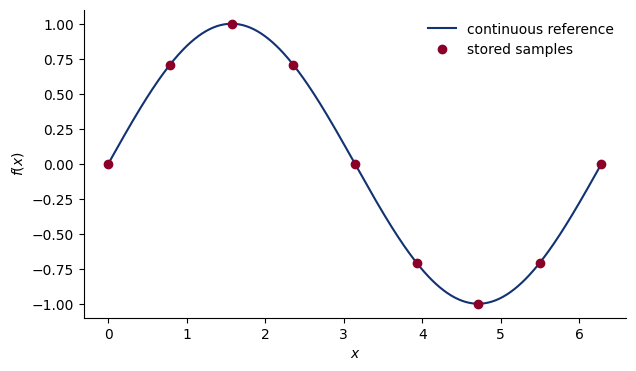

In [2]:
x = np.linspace(0.0, 2.0 * np.pi, 9)
f = np.sin(x)

print("shape:", f.shape)
print("dtype:", f.dtype)
print("samples:", f)

x_dense = np.linspace(0.0, 2.0 * np.pi, 401)
plt.plot(x_dense, np.sin(x_dense), color="#113273", label="continuous reference")
plt.plot(x, f, "o", color="#8B0029", label="stored samples")
plt.xlabel(r"$x$")
plt.ylabel(r"$f(x)$")
plt.legend(frameon=False)
plt.show()

## 2. Shape, indexing, and vectorization

Array shape records the number of entries along each axis. NumPy functions usually act elementwise.

In [3]:
A = np.arange(12.0).reshape(3, 4)

row = A[1, :]
block = A[:2, 1:3]
even_entries = A[A % 2 == 0]

print("A =\n", A)
print("shape:", A.shape)
print("row:", row)
print("block =\n", block)
print("even entries:", even_entries)

A =
 [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]]
shape: (3, 4)
row: [4. 5. 6. 7.]
block =
 [[1. 2.]
 [5. 6.]]
even entries: [ 0.  2.  4.  6.  8. 10.]


In [4]:
x = np.linspace(0.0, np.pi, 6)
y = np.sin(x)
z = y**2 + np.cos(x)**2

print("x:", x)
print("sin(x):", y)
print("sin(x)^2 + cos(x)^2:", z)
assert np.allclose(z, 1.0)

x: [0.       0.628319 1.256637 1.884956 2.513274 3.141593]
sin(x): [0.       0.587785 0.951057 0.951057 0.587785 0.      ]
sin(x)^2 + cos(x)^2: [1. 1. 1. 1. 1. 1.]


## 3. Linear algebra

Use matrix multiplication for $A\mathbf{x}$. Solve $A\mathbf{x}=\mathbf{b}$ directly and check the residual.

In [5]:
A = np.array([[3.0, 1.0],
              [1.0, 2.0]])
b = np.array([9.0, 8.0])

x_solution = np.linalg.solve(A, b)
residual = A @ x_solution - b

print("solution:", x_solution)
print("residual:", residual)
print("residual norm:", np.linalg.norm(residual))

assert np.linalg.norm(residual) < 1.0e-12

solution: [2. 3.]
residual: [0. 0.]
residual norm: 0.0


## 4. Root finding by bisection

Bisection requires a sign change on $[a,b]$. It is slow but reliable.

In [6]:
def bisection(func, left, right, tol=1.0e-12, max_iter=100):
    f_left = func(left)
    f_right = func(right)

    if f_left * f_right > 0:
        raise ValueError("The interval does not bracket a root.")

    for iteration in range(1, max_iter + 1):
        middle = 0.5 * (left + right)
        f_middle = func(middle)

        if abs(f_middle) < tol or 0.5 * (right - left) < tol:
            return middle, iteration

        if f_left * f_middle <= 0:
            right = middle
        else:
            left = middle
            f_left = f_middle

    raise RuntimeError("Bisection did not converge.")


root_function = lambda x: np.cos(x) - x
root, iterations = bisection(root_function, 0.0, 1.0)

print("root:", root)
print("iterations:", iterations)
print("residual:", root_function(root))

assert abs(root_function(root)) < 1.0e-12

root: 0.7390851332147577
iterations: 39
residual: 6.744604874597826e-13


## 5. Linear interpolation

np.interp evaluates the piecewise-linear curve through stored samples.

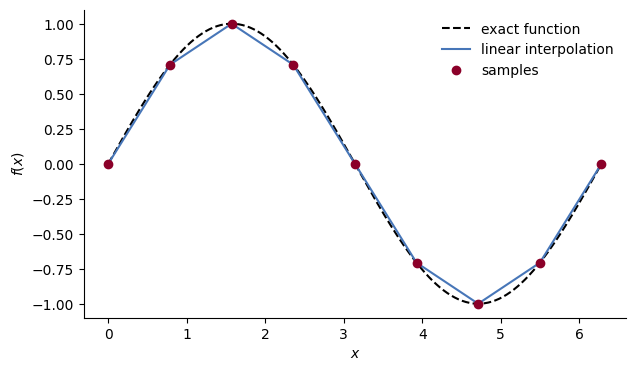

In [7]:
x_sample = np.linspace(0.0, 2.0 * np.pi, 9)
f_sample = np.sin(x_sample)

x_query = np.linspace(0.0, 2.0 * np.pi, 401)
f_linear = np.interp(x_query, x_sample, f_sample)

plt.plot(x_query, np.sin(x_query), "--", color="black", label="exact function")
plt.plot(x_query, f_linear, color="#4776B8", label="linear interpolation")
plt.plot(x_sample, f_sample, "o", color="#8B0029", label="samples")
plt.xlabel(r"$x$")
plt.ylabel(r"$f(x)$")
plt.legend(frameon=False)
plt.show()

## 6. Finite precision

A floating-point value is one point on a discrete grid.

In [8]:
computed = 0.1 + 0.2

print("0.1 + 0.2:", repr(computed))
print("equal to 0.3:", computed == 0.3)
print("close to 0.3:", np.isclose(computed, 0.3))
print("spacing near 0.3:", np.spacing(0.3))
print("previous float:", np.nextafter(0.3, -np.inf))
print("next float:", np.nextafter(0.3, np.inf))

assert np.isclose(computed, 0.3)

0.1 + 0.2: 0.30000000000000004
equal to 0.3: False
close to 0.3: True
spacing near 0.3: 5.551115123125783e-17
previous float: 0.29999999999999993
next float: 0.30000000000000004


## 7. Calculus on a grid

np.gradient estimates derivatives. np.trapezoid estimates integrals.

integral: 1.9958859727087146
integral error: 0.004114027291285405
maximum interior derivative error: 0.004056697511671814


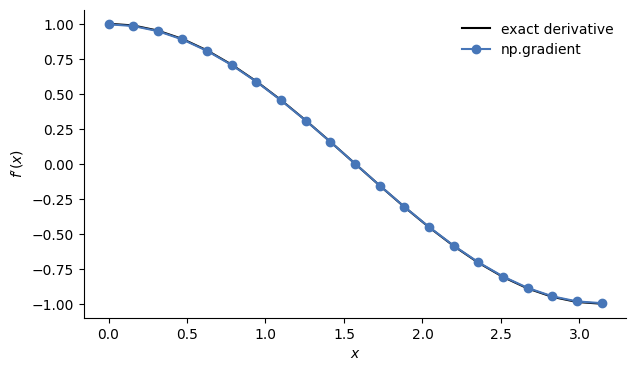

In [9]:
def grid_calculus(number_of_points):
    x = np.linspace(0.0, np.pi, number_of_points)
    f = np.sin(x)
    derivative = np.gradient(f, x)
    integral = np.trapezoid(f, x)

    interior = slice(1, -1)
    derivative_error = np.max(
        np.abs(derivative[interior] - np.cos(x[interior]))
    )
    integral_error = abs(integral - 2.0)

    return x, f, derivative, integral, derivative_error, integral_error


x, f, derivative, integral, derivative_error, integral_error = grid_calculus(21)

print("integral:", integral)
print("integral error:", integral_error)
print("maximum interior derivative error:", derivative_error)

plt.plot(x, np.cos(x), color="black", label="exact derivative")
plt.plot(x, derivative, "o-", color="#4776B8", label="np.gradient")
plt.xlabel(r"$x$")
plt.ylabel(r"$f'(x)$")
plt.legend(frameon=False)
plt.show()

## 8. Minimal verification

Repeat the calculation on finer grids. The errors should decrease.

In [10]:
results = []
for n in [11, 21, 41, 81]:
    x, f, derivative, integral, d_error, i_error = grid_calculus(n)
    results.append((n, x[1] - x[0], d_error, i_error))

print(f"{'n':>5} {'dx':>12} {'derivative error':>20} {'integral error':>18}")
for n, dx, d_error, i_error in results:
    print(f"{n:5d} {dx:12.5e} {d_error:20.5e} {i_error:18.5e}")

derivative_errors = np.array([row[2] for row in results])
integral_errors = np.array([row[3] for row in results])

assert np.all(np.diff(derivative_errors) < 0)
assert np.all(np.diff(integral_errors) < 0)

    n           dx     derivative error     integral error
   11  3.14159e-01          1.55672e-02        1.64765e-02
   21  1.57080e-01          4.05670e-03        4.11403e-03
   41  7.85398e-02          1.02460e-03        1.02819e-03
   81  3.92699e-02          2.56803e-04        2.57028e-04


## Practice

1. Replace sin(x) with another smooth function.
2. Change the number of sample points used for interpolation.
3. Find a different root with bisection.
4. Check every result with a residual or an exact reference.

Detailed error models and convergence rates are covered in Week 2.

## References

- [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- [numpy.linalg.solve](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html)
- [numpy.interp](https://numpy.org/doc/stable/reference/generated/numpy.interp.html)
- [numpy.gradient](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html)
- [numpy.trapezoid](https://numpy.org/doc/stable/reference/generated/numpy.trapezoid.html)
- [MIT 18.330: Introduction to Numerical Analysis](https://math.mit.edu/icg/resources/teaching/18.330/)
- [UC Berkeley Math 128A: Numerical Analysis](https://math.berkeley.edu/~andrewshi/teaching/w128a2025syllabus.pdf)
- [Georgia Tech CX/Math 4640: Numerical Analysis I](https://syllabus.gatech.edu/syllabi/4640/bg-bu-q)